First 5 Records
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  pe

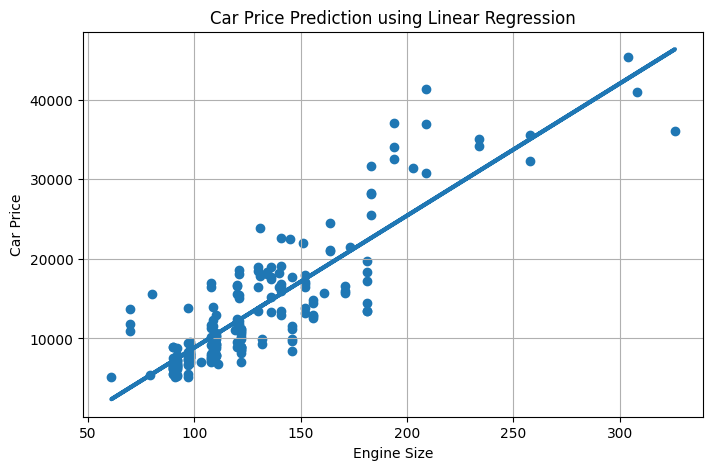

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==================================
# LOAD DATASET
# ==================================

df = pd.read_csv("CarPrice_Assignment.csv")

print("First 5 Records")
print(df.head())

# ==================================
# DATA CLEANING
# ==================================

print("\nMissing Values")
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("\nDataset Shape :", df.shape)

# ==================================
# FEATURES & TARGET
# ==================================

X = df[["enginesize"]]
y = df["price"]

# ==================================
# TRAIN TEST SPLIT
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==================================
# MODEL TRAINING
# ==================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Trained Successfully")

# ==================================
# PREDICTION
# ==================================

y_pred = model.predict(X_test)

# ==================================
# VALIDATION
# ==================================

r2 = r2_score(y_test, y_pred)

print("\nR2 Score :", round(r2, 4))

# ==================================
# USER INPUT
# ==================================

engine_size = float(
    input("\nEnter Engine Size : ")
)

user = pd.DataFrame(
    [[engine_size]],
    columns=["enginesize"]
)

predicted_price = model.predict(user)

print(
    "\nPredicted Car Price : ₹",
    round(predicted_price[0], 2)
)

# ==================================
# REGRESSION GRAPH
# ==================================

plt.figure(figsize=(8,5))

plt.scatter(
    df["enginesize"],
    df["price"]
)

plt.plot(
    df["enginesize"],
    model.predict(X),
    linewidth=3
)

plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Car Price Prediction using Linear Regression")

plt.grid(True)

plt.show()

In [2]:
df = pd.read_csv("CarPrice_Assignment.csv")
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [7]:
df = pd.read_csv("CarPrice_Assignment.csv")
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
print(df.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


In [8]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [9]:
df.drop_duplicates(inplace=True)

print("\nDataset Shape :", df.shape)


Dataset Shape : (205, 26)


In [10]:
X = df[["enginesize"]]
y = df["price"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
r2 = r2_score(y_test, y_pred)

print("\nR2 Score :", round(r2, 4))


R2 Score : 0.8041


In [15]:
engine_size = float(
    input("\nEnter Engine Size : ")
)

user = pd.DataFrame(
    [[engine_size]],
    columns=["enginesize"]
)

predicted_price = model.predict(user)

print(
    "\nPredicted Car Price : ₹",
    round(predicted_price[0], 2)
)


Enter Engine Size : 159

Predicted Car Price : ₹ 18627.52


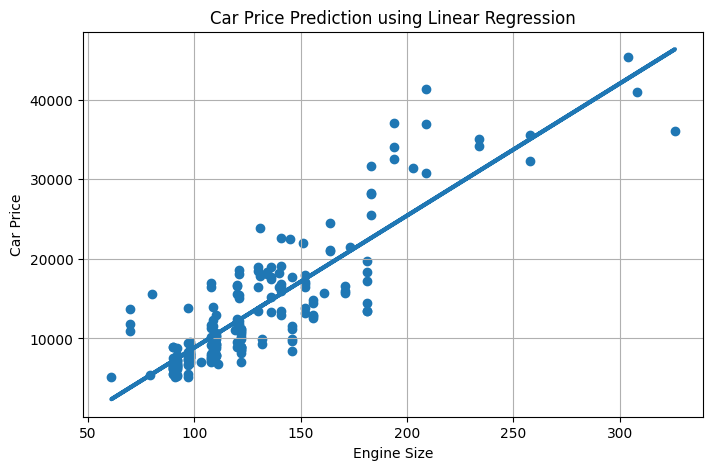

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["enginesize"],
    df["price"]
)

plt.plot(
    df["enginesize"],
    model.predict(X),
    linewidth=3
)

plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Car Price Prediction using Linear Regression")

plt.grid(True)

plt.show()